# Advanced Topics in Machine Learning - Assignment 0
## Task 5: Modality Gap in CLIP

In this task, we will investigate the Contrastive Language-Image Pre-training (CLIP) model. We'll explore its zero-shot classification capabilities, visualize the "modality gap" between its image and text embeddings, and attempt to bridge this gap using Procrustes analysis.
### 1. Setup and Imports

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.linalg import orthogonal_procrustes
from sklearn.manifold import TSNE
from torchvision import transforms
from torchvision.datasets import STL10
from transformers import CLIPModel, CLIPProcessor

os.environ["TQDM_NOTEBOOK"] = "0"
from tqdm import tqdm

np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)
print("CLIP Model ViT-B/32 loaded successfully.")


def custom_collate(batch):
    images, labels = zip(*batch)
    labels = torch.tensor(labels)
    return list(images), labels


stl10_test = STL10(root="data", split="test", download=True)
test_loader = torch.utils.data.DataLoader(
    stl10_test, batch_size=256, shuffle=False, collate_fn=custom_collate
)
print("STL-10 dataset loaded successfully.")

Using device: cuda


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

CLIP Model ViT-B/32 loaded successfully.
STL-10 dataset loaded successfully.


### 2. Zero-Shot Classification on STL-10
Here, we evaluate CLIP's zero-shot classification performance on the STL-10 test set.

We will use three different prompting strategies to see how the phrasing of class descriptions affects accuracy:
1. **Plain Labels**: e.g., "cat"
2. **Simple Prompt**: e.g., "a photo of a cat"
3. **Descriptive Prompt**: e.g., "a high-resolution photo of a cat"

In [ ]:
class_names = stl10_test.classes
prompts = {
    "Plain Labels": [f"{name}" for name in class_names],
    "Simple Prompt": [f"a photo of a {name}" for name in class_names],
    "Descriptive Prompt": [
        f"a clear, well-lit photo of a {name}" for name in class_names
    ],
}


def evaluate(prompts, dataloader, R=None):
    with torch.no_grad():
        # Process text prompts and get text features
        text_inputs = processor(text=prompts, return_tensors="pt", padding=True).to(
            device
        )
        text_features = model.get_text_features(**text_inputs)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        total_correct = 0
        total_samples = 0

        if R is not None:
            R_tensor = torch.tensor(R, dtype=torch.float32).to(device)

        for images, labels in tqdm(dataloader, desc="Evaluating"):
            labels = labels.to(device)

            # Process images and get image features
            image_inputs = processor(images=images, return_tensors="pt").to(device)
            image_features = model.get_image_features(**image_inputs)
            image_features /= image_features.norm(dim=-1, keepdim=True)

            if R is not None:
                image_features = (
                    image_features @ R_tensor
                )  # this matrix gets applied in the bridging modality gap section

            # Calculate similarity and make predictions
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            predictions = similarity.argmax(dim=-1)

            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [3]:
results = {}
for name, prompt_list in prompts.items():
    print(f"\n--- Evaluating: {name} ---")
    accuracy = evaluate(prompt_list, test_loader)
    results[name] = accuracy
    print(f"Accuracy for '{name}': {accuracy:.2f}%")

print("\n--- Zero-Shot Classification Accuracy Summary ---")
for name, acc in results.items():
    print(f"{name:<20}: {acc:.2f}%")
print("-------------------------------------------------")


--- Evaluating: Plain Labels ---


Evaluating: 100%|██████████| 32/32 [00:18<00:00,  1.76it/s]


Accuracy for 'Plain Labels': 96.25%

--- Evaluating: Simple Prompt ---


Evaluating: 100%|██████████| 32/32 [00:17<00:00,  1.88it/s]


Accuracy for 'Simple Prompt': 97.36%

--- Evaluating: Descriptive Prompt ---


Evaluating: 100%|██████████| 32/32 [00:16<00:00,  1.90it/s]

Accuracy for 'Descriptive Prompt': 96.58%

--- Zero-Shot Classification Accuracy Summary ---
Plain Labels        : 96.25%
Simple Prompt       : 97.36%
Descriptive Prompt  : 96.58%
-------------------------------------------------


In [ ]:
sample_size = 8
sample_indices = np.random.choice(len(stl10_test), sample_size, replace=False)
sample_data = torch.utils.data.Subset(stl10_test, sample_indices.tolist())
sample_loader = torch.utils.data.DataLoader(
    sample_data, batch_size=sample_size, collate_fn=custom_collate
)

sample_images, sample_labels = next(iter(sample_loader))

predictions_by_strategy = {}

for strategy_name, prompt_list in prompts.items():
    with torch.no_grad():
        # Get text features
        text_inputs = processor(text=prompt_list, return_tensors="pt", padding=True).to(
            device
        )
        text_features = model.get_text_features(**text_inputs)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        # Get image features
        image_inputs = processor(images=sample_images, return_tensors="pt").to(device)
        image_features = model.get_image_features(**image_inputs)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # Calculate predictions
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        predictions = similarity.argmax(dim=-1)
        predictions_by_strategy[strategy_name] = predictions.cpu()

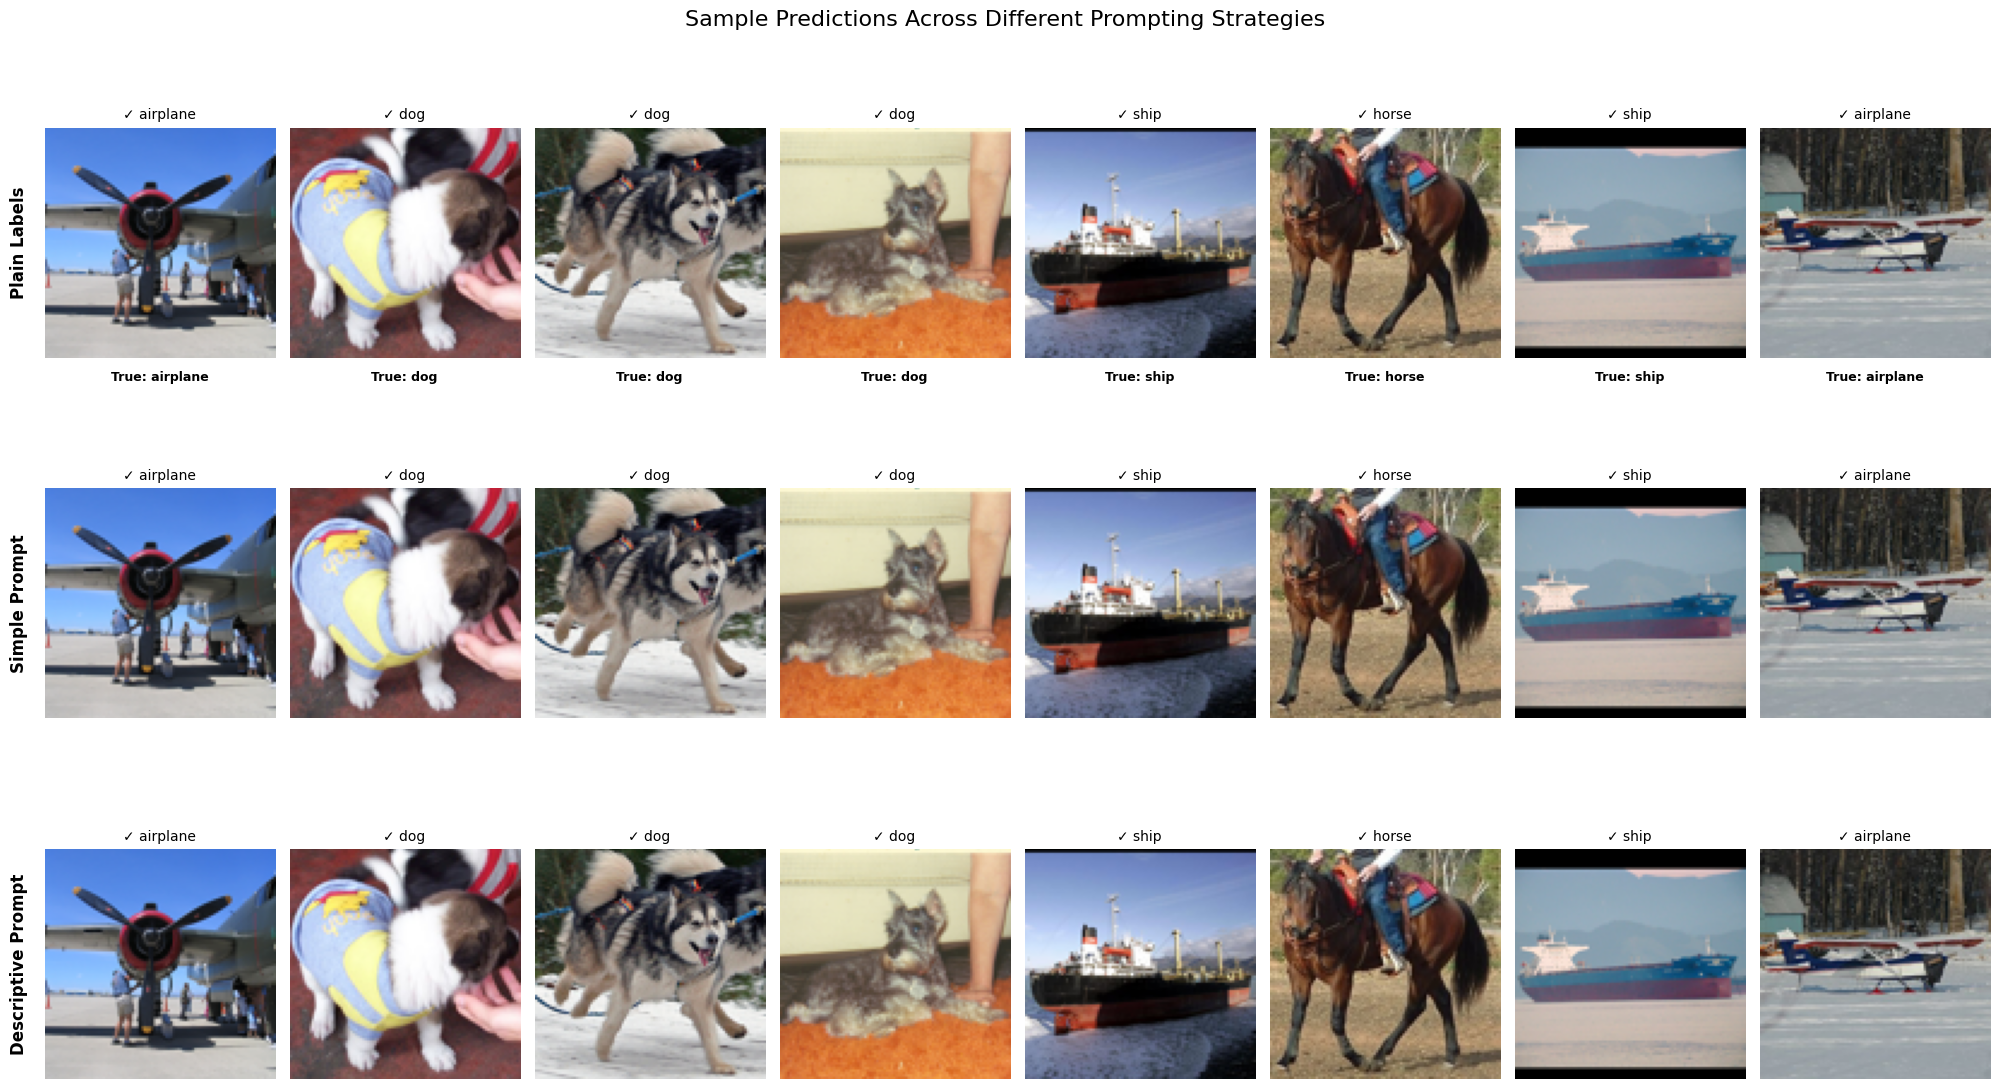


Prediction Comparison for Sample Images:

Image 1 - True Label: airplane
  Plain Labels        : airplane   ✓
  Simple Prompt       : airplane   ✓
  Descriptive Prompt  : airplane   ✓

Image 2 - True Label: dog
  Plain Labels        : dog        ✓
  Simple Prompt       : dog        ✓
  Descriptive Prompt  : dog        ✓

Image 3 - True Label: dog
  Plain Labels        : dog        ✓
  Simple Prompt       : dog        ✓
  Descriptive Prompt  : dog        ✓

Image 4 - True Label: dog
  Plain Labels        : dog        ✓
  Simple Prompt       : dog        ✓
  Descriptive Prompt  : dog        ✓

Image 5 - True Label: ship
  Plain Labels        : ship       ✓
  Simple Prompt       : ship       ✓
  Descriptive Prompt  : ship       ✓

Image 6 - True Label: horse
  Plain Labels        : horse      ✓
  Simple Prompt       : horse      ✓
  Descriptive Prompt  : horse      ✓

Image 7 - True Label: ship
  Plain Labels        : ship       ✓
  Simple Prompt       : ship       ✓
  Descriptive Prompt

In [ ]:
fig, axes = plt.subplots(len(prompts), sample_size, figsize=(20, 12))

for strategy_idx, (strategy_name, predictions) in enumerate(
    predictions_by_strategy.items()
):
    for img_idx in range(sample_size):
        row = strategy_idx if len(prompts) > 1 else 0
        col = img_idx

        axes[row, col].imshow(sample_images[img_idx])

        true_label = class_names[sample_labels[img_idx]]
        pred_label = class_names[predictions[img_idx]]
        correct = "✓" if sample_labels[img_idx] == predictions[img_idx] else "✗"

        axes[row, col].set_title(f"{correct} {pred_label}", fontsize=10)
        axes[row, col].axis("off")

        if strategy_idx == 0:
            axes[row, col].text(
                0.5,
                -0.1,
                f"True: {true_label}",
                transform=axes[row, col].transAxes,
                ha="center",
                fontsize=9,
                weight="bold",
            )

    axes[strategy_idx, 0].text(
        -0.15,
        0.5,
        strategy_name,
        transform=axes[strategy_idx, 0].transAxes,
        rotation=90,
        va="center",
        fontsize=12,
        weight="bold",
    )

plt.suptitle("Sample Predictions Across Different Prompting Strategies", fontsize=16)
plt.tight_layout()
plt.show()

print("\nPrediction Comparison for Sample Images:")
print("=" * 80)
for i in range(sample_size):
    true_label = class_names[sample_labels[i]]
    print(f"\nImage {i+1} - True Label: {true_label}")
    for strategy_name, predictions in predictions_by_strategy.items():
        pred_label = class_names[predictions[i]]
        correct = "✓" if sample_labels[i] == predictions[i] else "✗"
        print(f"  {strategy_name:<20}: {pred_label:<10} {correct}")

### 3. Exploring the Modality Gap
Now, we will visualize the embeddings from the image and text encoders to observe the "modality gap".

We expect to see that image embeddings and text embeddings form separate clusters in the feature space, even for the same class.

In [ ]:
best_prompt_name = max(results, key=results.get)
best_prompts = prompts[best_prompt_name]
print(f"Using prompts from '{best_prompt_name}' for visualization.")

subset_size = 100
subset_indices = np.random.choice(len(stl10_test), subset_size, replace=False)
subset_data = torch.utils.data.Subset(stl10_test, subset_indices)
subset_loader = torch.utils.data.DataLoader(
    subset_data, batch_size=subset_size, collate_fn=custom_collate
)

# Extract and normalize embeddings for the subset
with torch.no_grad():
    text_inputs = processor(text=best_prompts, return_tensors="pt", padding=True).to(
        device
    )
    text_features_full = model.get_text_features(**text_inputs)

    images_subset, labels_subset = next(iter(subset_loader))
    image_inputs = processor(images=images_subset, return_tensors="pt").to(device)
    image_features = model.get_image_features(**image_inputs)

    text_features_subset = text_features_full[labels_subset.cpu()]

image_features = image_features.cpu().numpy()
text_features_subset = text_features_subset.cpu().numpy()
image_features /= np.linalg.norm(image_features, axis=1, keepdims=True)
text_features_subset /= np.linalg.norm(text_features_subset, axis=1, keepdims=True)

Using prompts from 'Simple Prompt' for visualization.


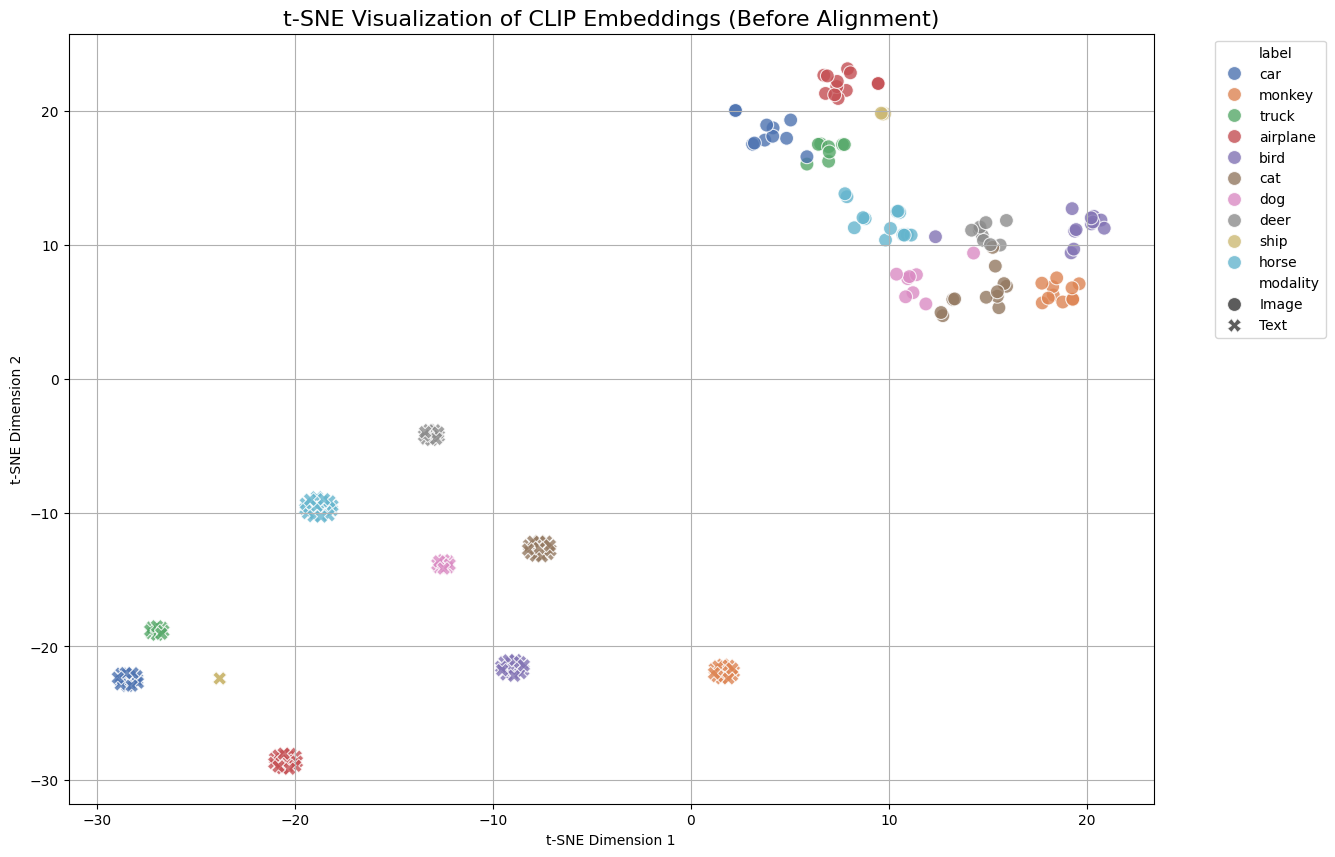

In [ ]:
tsne = TSNE(
    n_components=2, perplexity=15, random_state=42, init="random", learning_rate=200
)
all_features = np.vstack([image_features, text_features_subset])
tsne_features = tsne.fit_transform(all_features)

df = pd.DataFrame(
    {
        "x": tsne_features[:, 0],
        "y": tsne_features[:, 1],
        "label": [class_names[l] for l in labels_subset] * 2,
        "modality": ["Image"] * subset_size + ["Text"] * subset_size,
    }
)

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="label",
    style="modality",
    s=100,
    palette="deep",
    alpha=0.8,
)
plt.title("t-SNE Visualization of CLIP Embeddings (Before Alignment)", fontsize=16)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True)
plt.show()

### 4. Bridging the Modality Gap
We will now use the **orthogonal Procrustes transform** to find an optimal rotation matrix `R` that aligns the image embeddings (`X`) with the text embeddings (`Y`).

Shape of the learned rotation matrix R: (512, 512)


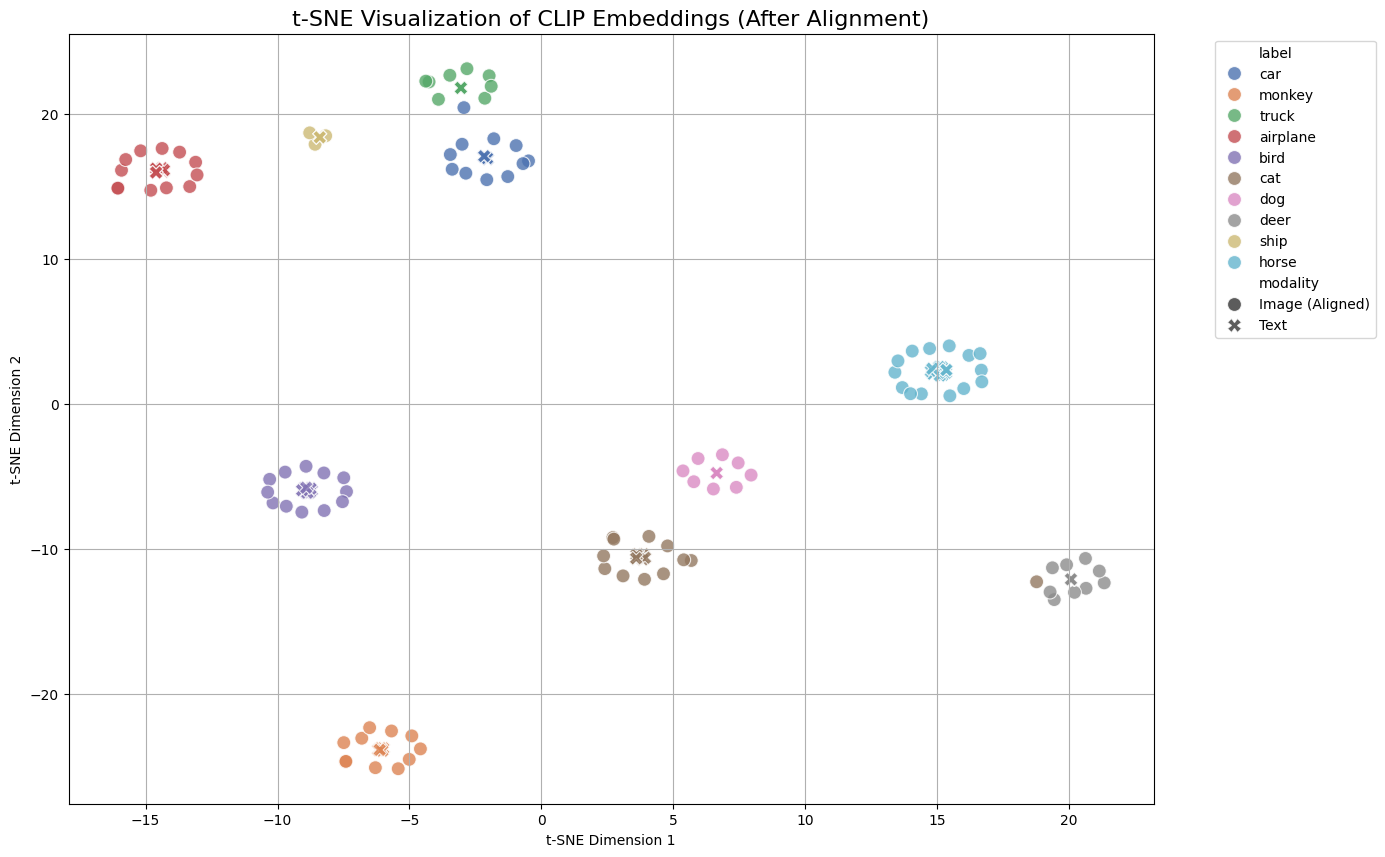

In [ ]:
R, _ = orthogonal_procrustes(image_features, text_features_subset)
print(f"Shape of the learned rotation matrix R: {R.shape}")

image_features_aligned = image_features @ R

# Re-run t-SNE on the aligned embeddings
all_features_aligned = np.vstack([image_features_aligned, text_features_subset])
tsne_features_aligned = tsne.fit_transform(all_features_aligned)

df_aligned = pd.DataFrame(
    {
        "x": tsne_features_aligned[:, 0],
        "y": tsne_features_aligned[:, 1],
        "label": [class_names[l] for l in labels_subset] * 2,
        "modality": ["Image (Aligned)"] * subset_size + ["Text"] * subset_size,
    }
)

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_aligned,
    x="x",
    y="y",
    hue="label",
    style="modality",
    s=100,
    palette="deep",
    alpha=0.8,
)
plt.title("t-SNE Visualization of CLIP Embeddings (After Alignment)", fontsize=16)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True)
plt.show()

### Re-computing Accuracy with Aligned Embeddings

In [ ]:
print(f"\n--- Re-evaluating with Procrustes Alignment using '{best_prompt_name}' ---")
aligned_accuracy = evaluate(best_prompts, test_loader, R=R)

print("\n--- Final Accuracy Comparison ---")
print(f"Original Accuracy : {results[best_prompt_name]:.2f}%")
print(f"Aligned Accuracy  : {aligned_accuracy:.2f}%")
print("---------------------------------")


--- Re-evaluating with Procrustes Alignment using 'Simple Prompt' ---


Evaluating: 100%|██████████| 32/32 [00:16<00:00,  1.89it/s]


--- Final Accuracy Comparison ---
Original Accuracy : 97.36%
Aligned Accuracy  : 97.15%
---------------------------------
